
Escenario                              |      PV Portafolio |         Impacto |     bps
-------------------------------------------------------------------------------------
Paralelo +300bps                       |        233,778,299 |     230,648,638 |  +144.2
Paralelo -300bps                       |       -230,918,350 |    -234,048,011 |  -146.3
Steepener (cortas -400, largas +200)   |       -307,645,583 |    -310,775,244 |  -194.2
Flattener (cortas +400, largas -200)   |        309,789,954 |     306,660,293 |  +191.7
Solo cortas up (+400)                  |        309,789,954 |     306,660,293 |  +191.7
Solo cortas down (-400)                |       -308,288,723 |    -311,418,384 |  -194.6

PEOR ESCENARIO: 6 — Solo cortas down (-400)
Impacto:        -311,418,384 CLP
PARTE I - CURVA CERO CUPON ICP
Tenor   DF_ICP  Zero_cont_%  Zero_SA_%   DF_CLP
0.25Y 0.988264     4.722018   4.778203 0.990632
0.50Y 0.976739     4.707169   4.763000 0.990696
0.75Y 0.965048     4.743609   4.800310 0.981

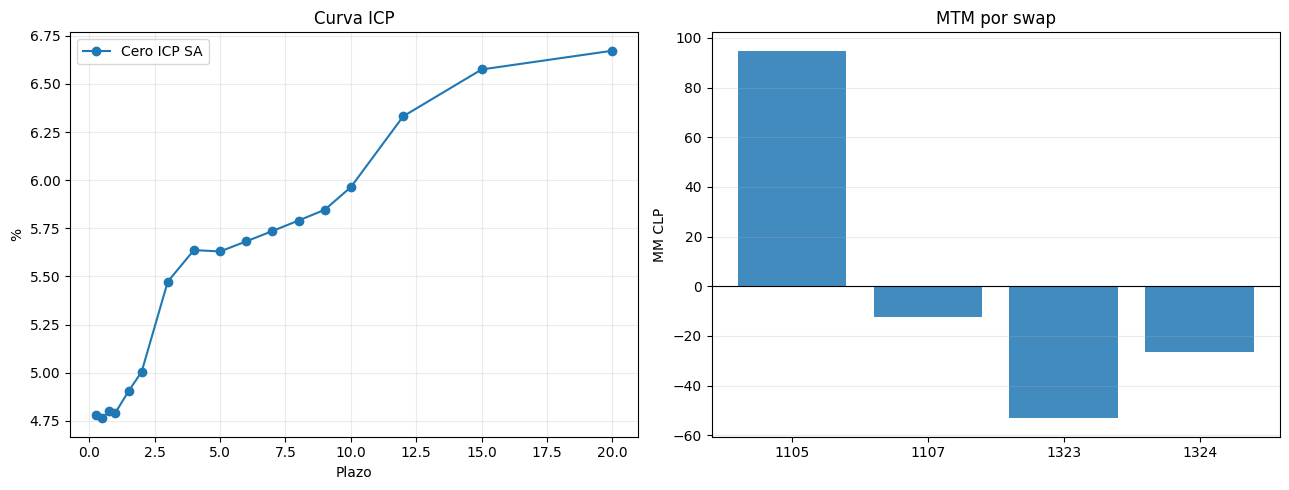

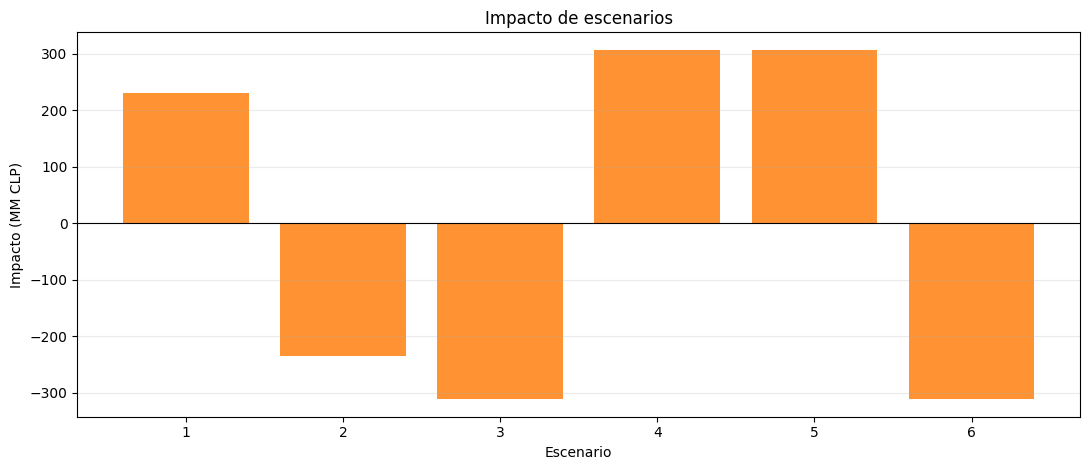

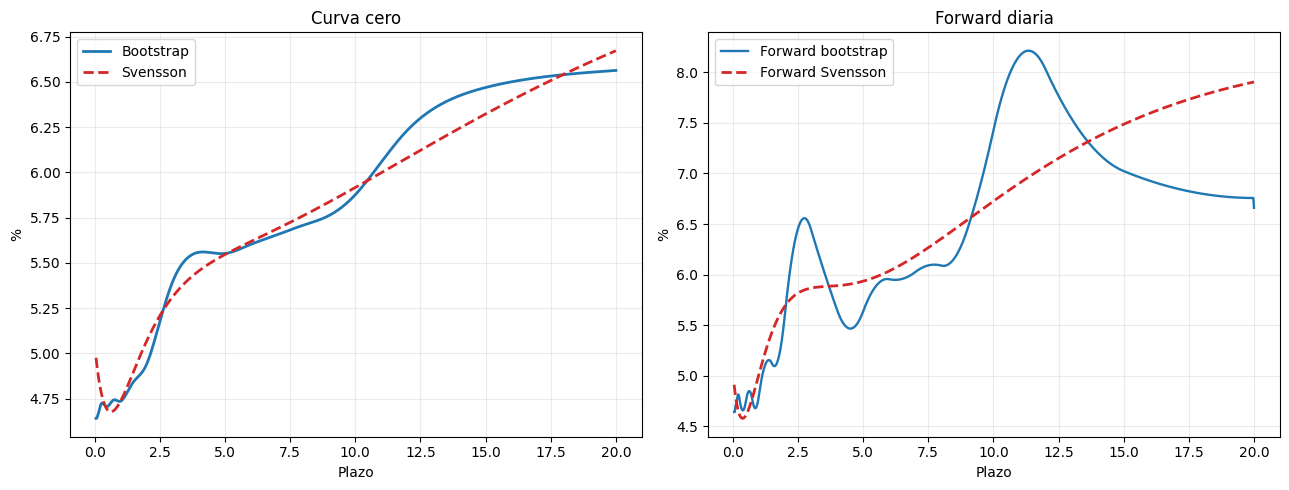

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
from calendar import monthrange
from scipy.optimize import minimize
from scipy.interpolate import CubicSpline
import warnings
warnings.filterwarnings("ignore")

VAL_DATE = date(2026, 3, 20)

COLORS = {
    "blue": "#1f77b4",
    "orange": "#ff7f0e",
    "red": "#d62728",
    "green": "#2ca02c",
    "gray": "#7f7f7f",
}

MKT = {
    "spot": 916.54,
    "swap_t": np.array([1/12, 2/12, 3/12, 6/12, 9/12, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20], dtype=float),
    "swap_r": np.array([4.650, 4.700, 4.750, 4.763, 4.829, 4.850, 4.902, 5.000, 5.450, 5.610, 5.610, 5.660, 5.710, 5.760, 5.810, 5.910, 6.210, 6.410, 6.510], dtype=float) / 100.0,
    "sofr_t": np.array([1/12, 3/12, 6/12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20], dtype=float),
    "sofr_r": np.array([3.687, 3.728, 3.788, 3.893, 3.658, 3.593, 3.593, 3.598, 3.612, 3.638, 3.649, 3.683, 3.704, 3.801, 3.711], dtype=float) / 100.0,
    "basis_t": np.array([0.5, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20], dtype=float),
    "basis_s": np.array([-83.8, -60.8, -61.2, -64.6, -54.6, -39.2, -40.0, -40.0, -42.5, -39.5, -38.5, -41.0, -51.5, -73.1, -98.1], dtype=float) / 10000.0,
    "ndf_t": np.array([1/12, 2/12, 3/12, 6/12, 9/12, 1.0], dtype=float),
    "ndf_pts": np.array([-0.30, -0.15, -0.24, 8.51, 9.12, 12.15], dtype=float),
}
MKT["ndf_fwd"] = MKT["spot"] + MKT["ndf_pts"]

BOOK = {
    "1105": {
        "cp": "BANCO 1", "nominal": 9e9, "inicio": date(2017, 4, 5), "cierre": date(2017, 4, 7), "venc": date(2027, 4, 7),
        "act": "ICP", "pas": "FIJO", "k_act": 0.0, "k_pas": 0.0405, "l_act": 0.046429, "l_pas": 0.0,
    },
    "1107": {
        "cp": "BANCO 2", "nominal": 1e9, "inicio": date(2017, 4, 11), "cierre": date(2017, 4, 13), "venc": date(2027, 4, 13),
        "act": "FIJO", "pas": "ICP", "k_act": 0.0393, "k_pas": 0.0, "l_act": 0.0, "l_pas": 0.046271,
    },
    "1323": {
        "cp": "BANCO 3", "nominal": 4e9, "inicio": date(2020, 4, 24), "cierre": date(2020, 4, 28), "venc": date(2026, 4, 28),
        "act": "FIJO", "pas": "ICP", "k_act": 0.0201, "k_pas": 0.0, "l_act": 0.0, "l_pas": 0.045899,
    },
    "1324": {
        "cp": "BANCO 2", "nominal": 2e9, "inicio": date(2020, 4, 24), "cierre": date(2020, 4, 28), "venc": date(2026, 4, 28),
        "act": "FIJO", "pas": "ICP", "k_act": 0.0204, "k_pas": 0.0, "l_act": 0.0, "l_pas": 0.045899,
    },
}

def yfrac(d1, d2):
    return (d2 - d1).days / 360.0

def add_months(d, n):
    y = d.year + (d.month - 1 + n) // 12
    m = (d.month - 1 + n) % 12 + 1
    dd = min(d.day, monthrange(y, m)[1])
    return date(y, m, dd)

def t_from_val(d):
    return yfrac(VAL_DATE, d)

def fmt_clp(x):
    return f"{x:,.2f}"

def tenor_tag(t):
    return f"{int(round(t))}Y" if abs(t - round(t)) < 1e-10 else f"{t:.2f}Y"

def interp_log_df(nodes_t, nodes_df):
    nodes_t = np.asarray(nodes_t, float)
    nodes_df = np.asarray(nodes_df, float)
    cs = CubicSpline(nodes_t, np.log(nodes_df), bc_type="natural")
    lo, hi = float(nodes_t[0]), float(nodes_t[-1])
    dlo, dhi = float(nodes_df[0]), float(nodes_df[-1])
    r_lo = -np.log(dlo) / lo
    r_hi = -np.log(dhi) / hi

    def f(t):
        x = float(t)
        if x <= 0:
            return 1.0
        if x <= lo:
            return np.exp(-r_lo * x)
        if x >= hi:
            return np.exp(-r_hi * x)
        return float(np.exp(cs(x)))
    return f

def semi_schedule(start_d, end_d, future_only=False):
    out = [start_d]
    d = start_d
    while True:
        d = add_months(d, 6)
        if d > end_d:
            break
        out.append(d)
    if out[-1] != end_d:
        out.append(end_d)
    if future_only:
        return [d for d in out if d > VAL_DATE]
    return out

def schedule_data(start_d, end_d):
    pay_dates = semi_schedule(start_d, end_d, future_only=True)
    prev = start_d
    while add_months(prev, 6) <= VAL_DATE:
        prev = add_months(prev, 6)
    alphas, times = [], []
    for d in pay_dates:
        alphas.append(yfrac(prev, d))
        times.append(t_from_val(d))
        prev = d
    return pay_dates, times, alphas

def bootstrap_grid(T):
    if T <= 1.0 + 1 / 24:
        return [float(T)]
    n = int(round(T * 2))
    return [i / 2.0 for i in range(1, n + 1)]

def annual_df(z, t):
    return 1.0 / (1.0 + z) ** t

def zero_cont(df, t):
    return 0.0 if t <= 1e-12 else -np.log(df) / t

def zero_sa(df, t):
    return 0.0 if t <= 1e-12 else 2.0 * (df ** (-1.0 / (2.0 * t)) - 1.0)

def build_discount_curve():
    sofr_t, sofr_r = MKT["sofr_t"], MKT["sofr_r"]
    basis_t, basis_s = MKT["basis_t"], MKT["basis_s"]
    ndf_t, ndf_fwd, spot = MKT["ndf_t"], MKT["ndf_fwd"], MKT["spot"]

    def df_usd(t):
        x = float(t)
        if x <= 0:
            return 1.0
        z = np.interp(np.clip(x, sofr_t[0], sofr_t[-1]), sofr_t, sofr_r)
        return annual_df(z, x)

    basis_cache = {}
    def basis_int(t, n=600):
        x = float(t)
        if x <= 0:
            return 0.0
        key = (round(x, 8), n)
        if key in basis_cache:
            return basis_cache[key]
        grid = np.linspace(1e-6, x, n)
        vals = np.interp(grid, basis_t, basis_s)
        area = np.sum((vals[1:] + vals[:-1]) * 0.5 * (grid[1:] - grid[:-1]))
        basis_cache[key] = area
        return area

    df_1y = df_usd(1.0) * (ndf_fwd[-1] / spot)
    ib_1y = basis_int(1.0)

    def df_disc(t):
        x = float(t)
        if x <= 0:
            return 1.0
        if x <= 1.0:
            fwd = np.interp(x, ndf_t, ndf_fwd)
            return df_usd(x) * (fwd / spot)
        return df_1y * (df_usd(x) / df_usd(1.0)) * np.exp(basis_int(x) - ib_1y)

    return df_disc

def build_proj_curve(par_t, par_r, disc_fn):
    proj_nodes_t, proj_nodes_df = [], []
    repairs = 0

    def proj_df_raw(t):
        x = float(t)
        if x <= 0:
            return 1.0
        if not proj_nodes_t:
            raise ValueError("Curva ICP no construida")
        if len(proj_nodes_t) == 1:
            r = zero_cont(proj_nodes_df[0], proj_nodes_t[0])
            return np.exp(-r * x)
        return interp_log_df(proj_nodes_t, proj_nodes_df)(x)

    def fallback_df(prev_t, last_t, p_prev, par_guess):
        dt = max(last_t - prev_t, 1e-10)

        if len(proj_nodes_df) >= 2:
            p_prev2 = proj_nodes_df[-2]
            t_prev2 = proj_nodes_t[-2]
            f_prev = -np.log(p_prev / p_prev2) / max(prev_t - t_prev2, 1e-10)
            f_use = max(f_prev, 1e-6)
        else:
            f_use = max(float(par_guess), 1e-6)

        p_last = p_prev * np.exp(-f_use * dt)
        return min(max(p_last, 1e-12), p_prev * (1.0 - 1e-10))

    for T, par in zip(par_t, par_r):
        sched = bootstrap_grid(T)
        a = [sched[0]] + [sched[i] - sched[i - 1] for i in range(1, len(sched))]
        disc = [disc_fn(u) for u in sched]
        pv_fix = par * sum(ai * di for ai, di in zip(a, disc))

        pv_flt_known = 0.0
        for i in range(len(sched) - 1):
            t0 = 0.0 if i == 0 else sched[i - 1]
            t1 = sched[i]
            p0 = 1.0 if t0 == 0 else proj_df_raw(t0)
            p1 = proj_df_raw(t1)
            pv_flt_known += disc[i] * (p0 / p1 - 1.0)

        last_t = sched[-1]
        prev_t = 0.0 if len(sched) == 1 else sched[-2]
        p_prev = 1.0 if prev_t == 0 else proj_df_raw(prev_t)
        rhs = pv_fix - pv_flt_known
        denom = 1.0 + rhs / disc[-1]

        if np.isfinite(denom) and denom > 1.0 + 1e-12:
            p_last = p_prev / denom
        else:
            p_last = np.nan

        if (not np.isfinite(p_last)) or (p_last <= 0.0) or (p_last > p_prev):
            p_last = fallback_df(prev_t, last_t, p_prev, par)
            repairs += 1

        proj_nodes_t.append(float(T))
        proj_nodes_df.append(float(p_last))

    proj_t = np.array(proj_nodes_t, dtype=float)
    proj_df_nodes = np.array(proj_nodes_df, dtype=float)
    proj_curve = interp_log_df(proj_t, proj_df_nodes)

    def df_proj(t):
        return proj_curve(t)

    def z_proj_cont(t):
        x = max(float(t), 1e-6)
        return zero_cont(df_proj(x), x)

    def z_proj_sa(t):
        x = max(float(t), 1e-6)
        return zero_sa(df_proj(x), x)

    return {
        "df_proj": df_proj,
        "proj_t": proj_t,
        "proj_df": proj_df_nodes,
        "z_proj_cont": z_proj_cont,
        "z_proj_sa": z_proj_sa,
        "repairs": repairs,
    }

def build_curves():
    df_disc = build_discount_curve()
    proj = build_proj_curve(MKT["swap_t"], MKT["swap_r"], df_disc)
    return {
        "df_disc": df_disc,
        "df_proj": proj["df_proj"],
        "proj_t": proj["proj_t"],
        "proj_df": proj["proj_df"],
        "z_proj_cont": proj["z_proj_cont"],
        "z_proj_sa": proj["z_proj_sa"],
    }

CURVES = build_curves()
df_clp = CURVES["df_disc"]
df_icp = CURVES["df_proj"]
z_icp = CURVES["z_proj_cont"]
z_icp_sa = CURVES["z_proj_sa"]

curve_grid = np.array([0.25, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 15, 20], dtype=float)
curve_table = pd.DataFrame({
    "Tenor": [tenor_tag(t) for t in curve_grid],
    "DF_ICP": [df_icp(t) for t in curve_grid],
    "Zero_cont_%": [100 * z_icp(t) for t in curve_grid],
    "Zero_SA_%": [100 * z_icp_sa(t) for t in curve_grid],
    "DF_CLP": [df_clp(t) for t in curve_grid],
})

def pv_fixed_leg(nom, rate, times, alphas):
    rows, pv = [], 0.0
    for i, (t, a) in enumerate(zip(times, alphas)):
        cpn = nom * rate * a
        amort = nom if i == len(times) - 1 else 0.0
        flow = cpn + amort
        disc = df_clp(t)
        val = flow * disc
        pv += val
        rows.append({"t": t, "alpha": a, "rate": rate, "interest": cpn, "amort": amort, "flow": flow, "df": disc, "pv": val})
    return pv, rows

def pv_float_leg(nom, first_fix, times, alphas):
    rows, pv = [], 0.0
    for i, (t, a) in enumerate(zip(times, alphas)):
        if i == 0 and first_fix > 0:
            interest = nom * first_fix * a
            used_rate = first_fix
        else:
            t_prev = 0.0 if i == 0 else times[i - 1]
            grow = df_icp(t_prev) / df_icp(t)
            interest = nom * (grow - 1.0)
            used_rate = interest / (nom * a) if a > 0 else 0.0
        amort = nom if i == len(times) - 1 else 0.0
        flow = interest + amort
        disc = df_clp(t)
        val = flow * disc
        pv += val
        rows.append({"t": t, "alpha": a, "rate": used_rate, "interest": interest, "amort": amort, "flow": flow, "df": disc, "pv": val})
    return pv, rows

def leg_value(kind, nom, k, l1, times, alphas):
    return pv_fixed_leg(nom, k, times, alphas) if kind == "FIJO" else pv_float_leg(nom, l1, times, alphas)

def price_swap(key, proj_fn=None, disc_fn=None):
    disc_fn = df_clp if disc_fn is None else disc_fn
    proj_fn = df_icp if proj_fn is None else proj_fn
    s = BOOK[key]
    pay_dates, times, alphas = schedule_data(s["inicio"], s["venc"])

    def fixed(nom, rate):
        pv = 0.0
        for i, (t, a) in enumerate(zip(times, alphas)):
            cash = nom * rate * a + (nom if i == len(times) - 1 else 0.0)
            pv += cash * disc_fn(t)
        return pv

    def floating(nom, first_fix):
        pv = 0.0
        for i, (t, a) in enumerate(zip(times, alphas)):
            if i == 0 and first_fix > 0:
                cpn = nom * first_fix * a
            else:
                prev = 0.0 if i == 0 else times[i - 1]
                cpn = nom * (proj_fn(prev) / proj_fn(t) - 1.0)
            pv += (cpn + (nom if i == len(times) - 1 else 0.0)) * disc_fn(t)
        return pv

    pv_act, flows_act = leg_value(s["act"], s["nominal"], s["k_act"], s["l_act"], times, alphas)
    pv_pas, flows_pas = leg_value(s["pas"], s["nominal"], s["k_pas"], s["l_pas"], times, alphas)
    mtm = pv_act - pv_pas

    if proj_fn is not df_icp or disc_fn is not df_clp:
        pv_act = fixed(s["nominal"], s["k_act"]) if s["act"] == "FIJO" else floating(s["nominal"], s["l_act"])
        pv_pas = fixed(s["nominal"], s["k_pas"]) if s["pas"] == "FIJO" else floating(s["nominal"], s["l_pas"])
        mtm = pv_act - pv_pas
        flows_act, flows_pas = [], []

    return {
        "swap": key, "cp": s["cp"], "act": s["act"], "pas": s["pas"],
        "pv_act": pv_act, "pv_pas": pv_pas, "mtm": mtm,
        "dates": pay_dates, "times": times, "alphas": alphas,
        "flows_act": flows_act, "flows_pas": flows_pas,
    }

BASE = {k: price_swap(k) for k in BOOK}
BASE_DF = pd.DataFrame([{
    "Swap": k, "Contraparte": v["cp"], "Activa": v["act"], "Pasiva": v["pas"],
    "PV activa": v["pv_act"], "PV pasiva": v["pv_pas"], "MTM": v["mtm"]
} for k, v in BASE.items()])
PORT_BASE = BASE_DF["MTM"].sum()

def shock(T, sc):
    corta = T <= 2.0
    larga = T > 2.0

    if sc == 1:
        return 0.0300
    if sc == 2:
        return -0.0300
    if sc == 3:
        return -0.0400 if corta else 0.0200
    if sc == 4:
        return 0.0400 if corta else -0.0200
    if sc == 5:
        return 0.0400 if corta else 0.0
    if sc == 6:
        return -0.0400 if corta else 0.0

    return 0.0

def apply_sc(par_tenors, par_rates, sc):
    shocks = np.array([shock(float(T), sc) for T in par_tenors])
    return np.clip(par_rates + shocks, 0.0001, None), shocks

SCENARIO_NAMES = {
    1: "Paralelo +300bps",
    2: "Paralelo -300bps",
    3: "Steepener (cortas -400, largas +200)",
    4: "Flattener (cortas +400, largas -200)",
    5: "Solo cortas up (+400)",
    6: "Solo cortas down (-400)",
}

scenario_rows = []
scenario_detail = {}
scenario_proj = {}
nom_tot = sum(s["nominal"] for s in BOOK.values())

print(f"\n{'Escenario':<38} | {'PV Portafolio':>18} | {'Impacto':>15} | {'bps':>7}")
print("-" * 85)

for sid in range(1, 7):
    par_rates_sc, shocks_sc = apply_sc(MKT["swap_t"], MKT["swap_r"], sid)
    proj_sc_pack = build_proj_curve(MKT["swap_t"], par_rates_sc, df_clp)
    proj_sc = proj_sc_pack["df_proj"]
    scenario_proj[sid] = proj_sc

    rows = []
    total = 0.0
    for k in BOOK:
        px = price_swap(k, proj_sc, df_clp)
        total += px["mtm"]
        rows.append({
            "Swap": k,
            "Valor shock": px["mtm"],
            "Impacto": px["mtm"] - BASE[k]["mtm"]
        })

    impacto = total - PORT_BASE
    bps = impacto / nom_tot * 10000

    scenario_detail[sid] = pd.DataFrame(rows)
    scenario_rows.append({
        "Escenario": sid,
        "Nombre": SCENARIO_NAMES[sid],
        "PV Portafolio": total,
        "Impacto": impacto,
        "bps": bps
    })

    print(f"{SCENARIO_NAMES[sid]:<38} | {total:>18,.0f} | {impacto:>15,.0f} | {bps:>+7.1f}")

SCENARIOS_DF = pd.DataFrame(scenario_rows)
WORST_ID = int(SCENARIOS_DF.iloc[SCENARIOS_DF["Impacto"].idxmin()]["Escenario"])
WORST_DELTA = float(SCENARIOS_DF.loc[SCENARIOS_DF["Escenario"] == WORST_ID, "Impacto"].iloc[0])

print(f"\nPEOR ESCENARIO: {WORST_ID} — {SCENARIO_NAMES[WORST_ID]}")
print(f"Impacto:        {WORST_DELTA:,.0f} CLP")

def par_rate_market(tenor):
    return np.interp(float(tenor), MKT["swap_t"], MKT["swap_r"])

def market_times(tenor):
    T = float(tenor)
    if T <= 1.0 + 1 / 24:
        sched = [T]
    else:
        n = int(round(T * 2))
        sched = [i / 2.0 for i in range(1, n + 1)]
    alphas = [sched[0]] + [sched[i] - sched[i - 1] for i in range(1, len(sched))]
    return sched, alphas

def market_swap_value(tenor, nominal, direction, shock_id=None):
    proj = df_icp if shock_id is None else scenario_proj[shock_id]
    disc = df_clp
    times, alphas = market_times(tenor)
    k = par_rate_market(tenor)
    pv_fix, pv_flt = 0.0, 0.0

    for i, (t, a) in enumerate(zip(times, alphas)):
        fix_flow = nominal * k * a + (nominal if i == len(times) - 1 else 0.0)
        pv_fix += fix_flow * disc(t)

        prev = 0.0 if i == 0 else times[i - 1]
        flt_flow = nominal * (proj(prev) / proj(t) - 1.0) + (nominal if i == len(times) - 1 else 0.0)
        pv_flt += flt_flow * disc(t)

    if direction == "receive_fixed":
        return pv_fix - pv_flt
    if direction == "pay_fixed":
        return pv_flt - pv_fix
    raise ValueError("direction invalida")

hedge_candidates = []
target_abs = 0.5 * abs(WORST_DELTA)

for ten in MKT["swap_t"]:
    for side in ["receive_fixed", "pay_fixed"]:
        delta_1bn = market_swap_value(ten, 1e9, side, shock_id=WORST_ID) - market_swap_value(ten, 1e9, side, shock_id=None)
        if np.sign(delta_1bn) == 0 or np.sign(delta_1bn) == np.sign(WORST_DELTA):
            continue
        raw = -0.5 * WORST_DELTA / (delta_1bn / 1e9)
        if raw <= 0:
            continue
        nom = max(500e6, round(raw / 500e6) * 500e6)
        hedge = market_swap_value(ten, nom, side, shock_id=WORST_ID) - market_swap_value(ten, nom, side, shock_id=None)
        post = WORST_DELTA + hedge

        hedge_candidates.append({
            "tenor": ten,
            "side": side,
            "nominal": nom,
            "delta_1bn": delta_1bn,
            "hedge_delta": hedge,
            "post_delta": post,
            "reduction_pct": 100 * (1 - abs(post) / abs(WORST_DELTA)),
            "gap": abs(abs(post) - target_abs),
            "flip": int(np.sign(post) != np.sign(WORST_DELTA)),
        })

HEDGE_DF = pd.DataFrame(hedge_candidates).sort_values(["flip", "gap", "nominal"], ascending=[True, True, True]).reset_index(drop=True)
BEST_HEDGE = HEDGE_DF.iloc[0].to_dict()

def sv_zero(t, b0, b1, b2, b3, tau1, tau2):
    x = float(t)
    if x <= 1e-8:
        return b0 + b1
    u1, u2 = x / tau1, x / tau2
    e1, e2 = np.exp(-u1), np.exp(-u2)
    f1 = (1 - e1) / u1
    f2 = f1 - e1
    f3 = (1 - e2) / u2 - e2
    return b0 + b1 * f1 + b2 * f2 + b3 * f3

def sv_df(t, p):
    x = float(t)
    return 1.0 if x <= 0 else np.exp(-sv_zero(x, *p) * x)

def sv_fwd(t, b0, b1, b2, b3, tau1, tau2):
    x = float(t)
    if x <= 1e-8:
        return b0 + b1
    return b0 + b1 * np.exp(-x / tau1) + b2 * (x / tau1) * np.exp(-x / tau1) + b3 * (x / tau2) * np.exp(-x / tau2)

def portfolio_with_proj(proj_fn):
    total = 0.0
    for key, s in BOOK.items():
        _, times, alphas = schedule_data(s["inicio"], s["venc"])

        def leg(kind, k, l1):
            pv = 0.0
            for i, (t, a) in enumerate(zip(times, alphas)):
                if kind == "FIJO":
                    cpn = s["nominal"] * k * a
                else:
                    if i == 0 and l1 > 0:
                        cpn = s["nominal"] * l1 * a
                    else:
                        prev = 0.0 if i == 0 else times[i - 1]
                        cpn = s["nominal"] * (proj_fn(prev) / proj_fn(t) - 1.0)
                pv += (cpn + (s["nominal"] if i == len(times) - 1 else 0.0)) * df_clp(t)
            return pv

        total += leg(s["act"], s["k_act"], s["l_act"]) - leg(s["pas"], s["k_pas"], s["l_pas"])
    return total

z_ref = np.array([z_icp(t) for t in curve_grid], dtype=float)
w_ref = np.array([0.5, 0.5, 1, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2], dtype=float)

def sv_obj(p):
    b0, b1, b2, b3, tau1, tau2 = p
    if tau1 <= 0.05 or tau2 <= 0.05 or tau2 <= tau1:
        return 1e12
    z_fit = np.array([sv_zero(t, *p) for t in curve_grid], dtype=float)
    err_curve = np.sum(w_ref * (z_fit - z_ref) ** 2)
    try:
        pv_sv = portfolio_with_proj(lambda x: sv_df(x, p))
    except Exception:
        return 1e12
    err_pv = ((pv_sv - PORT_BASE) / 1e6) ** 2
    return 1e6 * err_curve + err_pv

rng = np.random.default_rng(42)
bounds = [(0.00, 0.20), (-0.20, 0.20), (-0.20, 0.20), (-0.20, 0.20), (0.10, 10.0), (0.20, 20.0)]
best = None
best_fun = np.inf

for _ in range(30):
    x0 = np.array([
        rng.uniform(0.03, 0.08),
        rng.uniform(-0.05, 0.02),
        rng.uniform(-0.05, 0.05),
        rng.uniform(-0.05, 0.05),
        rng.uniform(0.5, 3.0),
        rng.uniform(2.0, 10.0),
    ])
    try:
        res = minimize(sv_obj, x0, method="L-BFGS-B", bounds=bounds, options={"maxiter": 5000})
        if res.success and res.fun < best_fun:
            best = res
            best_fun = res.fun
    except Exception:
        pass

if best is None:
    raise RuntimeError("No fue posible calibrar Svensson")

SV = best.x
SV_PV = portfolio_with_proj(lambda x: sv_df(x, SV))
SV_ERR = SV_PV - PORT_BASE
SV_RMSE_BP = np.sqrt(np.mean((np.array([sv_zero(t, *SV) for t in curve_grid]) - z_ref) ** 2)) * 10000
SV_DF = pd.DataFrame([{
    "beta0": SV[0], "beta1": SV[1], "beta2": SV[2], "beta3": SV[3],
    "tau1": SV[4], "tau2": SV[5], "PV base": PORT_BASE, "PV Svensson": SV_PV,
    "Error PV": SV_ERR, "RMSE zero bp": SV_RMSE_BP,
}])

print("=" * 88)
print("PARTE I - CURVA CERO CUPON ICP")
print("=" * 88)
print(curve_table.to_string(index=False, float_format=lambda x: f"{x:0.6f}"))

print("\n" + "=" * 88)
print("PARTE II - VALORIZACION SWAPS")
print("=" * 88)
print(BASE_DF.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print(f"\nVALOR TOTAL CARTERA: {fmt_clp(PORT_BASE)} CLP")

print("\n" + "=" * 88)
print("PARTE III - ESCENARIOS")
print("=" * 88)
print(SCENARIOS_DF.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print(f"\nPEOR ESCENARIO: {WORST_ID} - {SCENARIO_NAMES[WORST_ID]}")

print("\n" + "=" * 88)
print("PARTE IV - COBERTURA")
print("=" * 88)
print(HEDGE_DF[["tenor", "side", "nominal", "hedge_delta", "post_delta", "reduction_pct"]].head(10).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))
print("\nCOBERTURA ELEGIDA:")
print(pd.DataFrame([BEST_HEDGE]).to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

print("\n" + "=" * 88)
print("PARTE V - SVENSSON")
print("=" * 88)
print(SV_DF.to_string(index=False, float_format=lambda x: f"{x:,.6f}"))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(curve_grid, [100 * z_icp_sa(t) for t in curve_grid], "o-", color=COLORS["blue"], label="Cero ICP SA")
ax[0].set_title("Curva ICP")
ax[0].set_xlabel("Plazo")
ax[0].set_ylabel("%")
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].bar(BASE_DF["Swap"].astype(str), BASE_DF["MTM"] / 1e6, color=COLORS["blue"], alpha=0.85)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_title("MTM por swap")
ax[1].set_ylabel("MM CLP")
ax[1].grid(True, axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(SCENARIOS_DF["Escenario"].astype(str), SCENARIOS_DF["Impacto"] / 1e6, color=COLORS["orange"], alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("Impacto de escenarios")
ax.set_xlabel("Escenario")
ax.set_ylabel("Impacto (MM CLP)")
ax.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plot_t = np.linspace(0.05, 20.0, 800)
boot_zero = np.array([z_icp(t) for t in plot_t], dtype=float)
sv_zero_curve = np.array([sv_zero(t, *SV) for t in plot_t], dtype=float)
boot_fwd = np.array([
    -(np.log(df_icp(t + 1/365)) - np.log(df_icp(max(1e-4, t - 1/365)))) / ((t + 1/365) - max(1e-4, t - 1/365))
    for t in plot_t
], dtype=float)
sv_fwd_curve = np.array([sv_fwd(t, *SV) for t in plot_t], dtype=float)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(plot_t, 100 * boot_zero, color=COLORS["blue"], lw=2, label="Bootstrap")
ax[0].plot(plot_t, 100 * sv_zero_curve, color=COLORS["red"], lw=2, ls="--", label="Svensson")
ax[0].set_title("Curva cero")
ax[0].set_xlabel("Plazo")
ax[0].set_ylabel("%")
ax[0].grid(True, alpha=0.25)
ax[0].legend()

ax[1].plot(plot_t, 100 * boot_fwd, color=COLORS["blue"], lw=1.7, label="Forward bootstrap")
ax[1].plot(plot_t, 100 * sv_fwd_curve, color=COLORS["red"], lw=2, ls="--", label="Forward Svensson")
ax[1].set_title("Forward diaria")
ax[1].set_xlabel("Plazo")
ax[1].set_ylabel("%")
ax[1].grid(True, alpha=0.25)
ax[1].legend()
plt.tight_layout()
plt.show()
